# 5th experiment: Multiespectral simulation

Hyperspectral imaging systems are very expensive, so the possibility of using a multispectral acquisition system can be studied, that is, using an RGB camera combined with additional optical filters. Starting from the hyperspectral information, the system can be reduced to a multispectral one. Since the spectral bands form clusters, these subsets can be selected so that, by applying a filter, the information from a specific spectral region is retained.

## Import libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

## Import data

In [2]:
def load_data():
    data = loadmat('dataset.mat')

    X_train = data['X_train']
    y_train = data['y_train'].ravel()

    X_test = data['X_test']
    y_test = data['y_test'].ravel()

    return X_train, y_train, X_test, y_test

#X variables are the pixels and Y variables are the labels
X_train, y_train, X_test, y_test = load_data()

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (43507, 121)
Train y: (43507,)
Test X: (10809, 121)
Test y: (10809,)


In [3]:
class_names = {
    12: "Sustrato Algodón-lino",
    62: "Esmalte-GA",
    63: "Lapislázuli-GA",
    64: "BlancoPb-GA",
    65: "Calcita-GA",
    85: "Esmalte-CH",
    87: "BlancoPb-CH",
    88: "Calcita-CH",
    109: "Imperial Yellow Ink-GA",
    117: "Azafrán-GA",
}

## 6 filters system

In [4]:
lambda_nm = 400 + 5*np.arange(121)

In [5]:
filtros_6 = {
    "Filtro 1": (0, 12),
    "Filtro 2": (12, 24),
    "Filtro 3": (27, 40),
    "Filtro 4": (44, 51),
    "Filtro 5": (53, 61),
    "Filtro 6": (63, 70),
}

In [6]:
def crear_multiespectral(X, filtros):                       #Creamos el sistema multiespectral
    canales = []                                            #hacemos una lista con los canales que tendría un sensor multiespectral

    for nombre, (bmin, bmax) in filtros.items():            #Recorremos cada filtro
        canal = X[:, bmin:bmax+1].mean(axis=1)              #Cogemos las muestras de la banda del filtro y las promediamos
        canales.append(canal)                               #$\text{canal} = \frac{1}{N} \sum_{i=bmin}^{bmax} X_i$

    return np.vstack(canales).T

In [7]:
X_train_6f = crear_multiespectral(X_train, filtros_6)
X_test_6f  = crear_multiespectral(X_test, filtros_6)

print(X_train_6f.shape)
print(X_test_6f.shape)

(43507, 6)
(10809, 6)


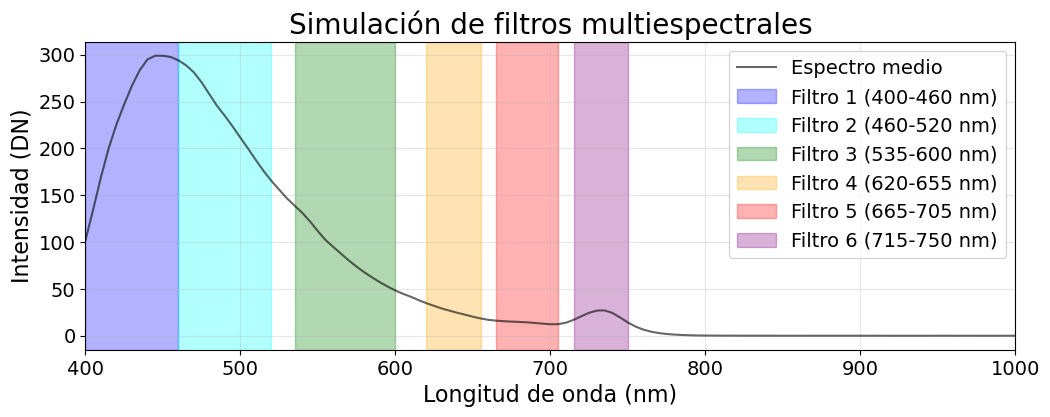

In [8]:
plt.figure(figsize=(12,4))

espectro = X_train.mean(axis=0)
plt.plot(lambda_nm, espectro, color="black", alpha=0.6, label="Espectro medio")

colores = ["blue", "cyan", "green", "orange", "red", "purple"]

for i, (nombre, (bmin, bmax)) in enumerate(filtros_6.items()):
    
    lmin = lambda_nm[bmin]
    lmax = lambda_nm[bmax]
    
    plt.axvspan(
        lmin,
        lmax,
        color=colores[i],
        alpha=0.3,
        label=f"{nombre} ({lmin:.0f}-{lmax:.0f} nm)"
    )

plt.xlabel("Longitud de onda (nm)",fontsize=16)
plt.ylabel("Intensidad (DN)",fontsize=16)
plt.title("Simulación de filtros multiespectrales",fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.xlim(400, 1000)

plt.show()

## Performance metrics study of SVM classifier

In [9]:
model_6f = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
])

model_6f.fit(X_train_6f, y_train)

y_pred_6f = model_6f.predict(X_test_6f)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred_6f))
print(classification_report(y_test, y_pred_6f, digits=4))

Accuracy: 0.7808307891571838
              precision    recall  f1-score   support

          12     0.4568    0.9790    0.6230      1000
          62     0.9988    0.9474    0.9724       856
          63     0.7370    0.7435    0.7402       803
          64     0.9128    0.7008    0.7929       792
          65     0.9484    0.9093    0.9285       364
          85     0.9653    1.0000    0.9824       334
          87     1.0000    0.6214    0.7665      1001
          88     0.9974    0.6400    0.7797      2975
         109     0.7194    0.8644    0.7852      2094
         117     0.7161    0.8424    0.7741       590

    accuracy                         0.7808     10809
   macro avg     0.8452    0.8248    0.8145     10809
weighted avg     0.8503    0.7808    0.7893     10809



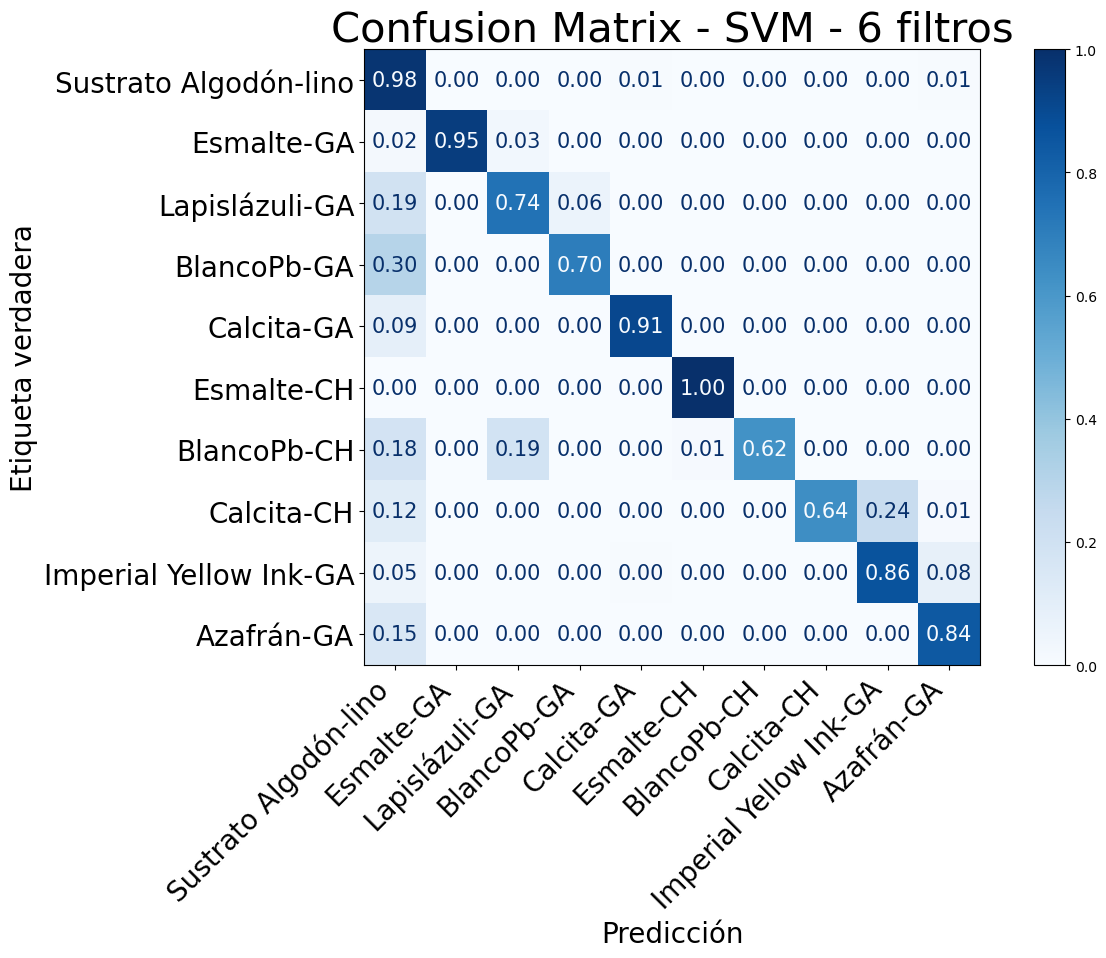

In [11]:
labels = np.unique(y_test)
display_labels = [class_names[l] for l in labels]

fig, ax = plt.subplots(figsize=(14, 8))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_6f,
    labels=labels,
    display_labels=display_labels,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - SVM - 6 filtros", fontsize=30)

for text in ax.texts:
    text.set_fontsize(15)

ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=20)
ax.set_yticklabels(display_labels, rotation=0, fontsize=20)

ax.set_xlabel("Predicción", fontsize=20)
ax.set_ylabel("Etiqueta verdadera", fontsize=20)

plt.show()

## 10 filters system

In [12]:
filtros_10 = {
    "F1":  (0, 6),
    "F2":  (6, 12),
    "F3":  (12, 18),
    "F4":  (18, 24),
    "F5":  (27, 34),
    "F6":  (34, 40),
    "F7":  (44, 51),
    "F8":  (53, 57),
    "F9":  (57, 61),
    "F10": (63, 70),
}

In [13]:
X_train_10f = crear_multiespectral(X_train, filtros_10)
X_test_10f  = crear_multiespectral(X_test, filtros_10)

print(X_train_10f.shape)
print(X_test_10f.shape)

(43507, 10)
(10809, 10)


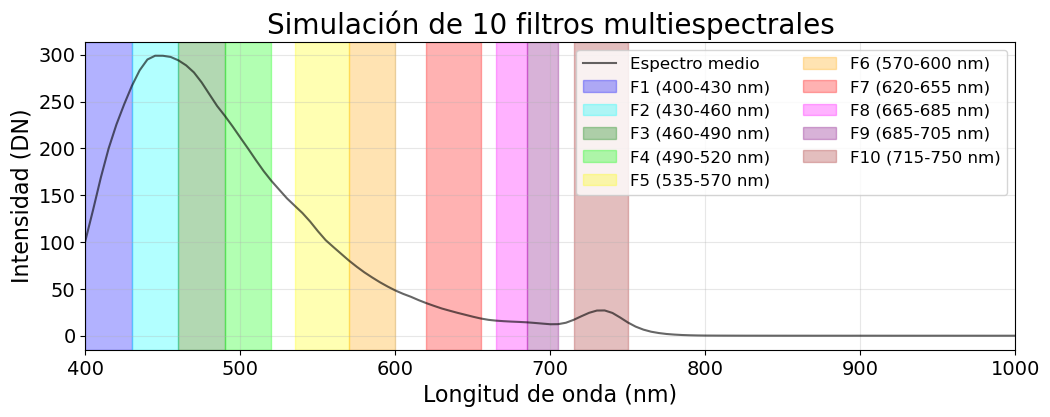

In [14]:
plt.figure(figsize=(12,4))

espectro = X_train.mean(axis=0)
plt.plot(lambda_nm, espectro, color="black", alpha=0.6, label="Espectro medio")

colores = [
    "blue", "cyan", "green", "lime",
    "yellow", "orange", "red",
    "magenta", "purple", "brown"
]

for i, (nombre, (bmin, bmax)) in enumerate(filtros_10.items()):
    
    lmin = lambda_nm[bmin]
    lmax = lambda_nm[bmax]
    
    plt.axvspan(
        lmin,
        lmax,
        color=colores[i],
        alpha=0.3,
        label=f"{nombre} ({lmin:.0f}-{lmax:.0f} nm)"
    )

plt.xlabel("Longitud de onda (nm)", fontsize=16)
plt.ylabel("Intensidad (DN)", fontsize=16)
plt.title("Simulación de 10 filtros multiespectrales", fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=12, ncol=2)  
plt.grid(alpha=0.3)

plt.xlim(400, 1000)

plt.show()

In [15]:
model_10f = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
])

model_10f.fit(X_train_10f, y_train)

y_pred_10f = model_10f.predict(X_test_10f)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred_10f))
print(classification_report(y_test, y_pred_10f, digits=4))

Accuracy: 0.7828661300767878
              precision    recall  f1-score   support

          12     0.4572    0.9830    0.6241      1000
          62     1.0000    0.9568    0.9779       856
          63     0.7094    0.7235    0.7164       803
          64     0.9158    0.7412    0.8193       792
          65     0.9526    0.9396    0.9461       364
          85     0.9598    1.0000    0.9795       334
          87     1.0000    0.5574    0.7158      1001
          88     1.0000    0.6568    0.7929      2975
         109     0.7528    0.8625    0.8039      2094
         117     0.6535    0.8441    0.7367       590

    accuracy                         0.7829     10809
   macro avg     0.8401    0.8265    0.8113     10809
weighted avg     0.8524    0.7829    0.7910     10809



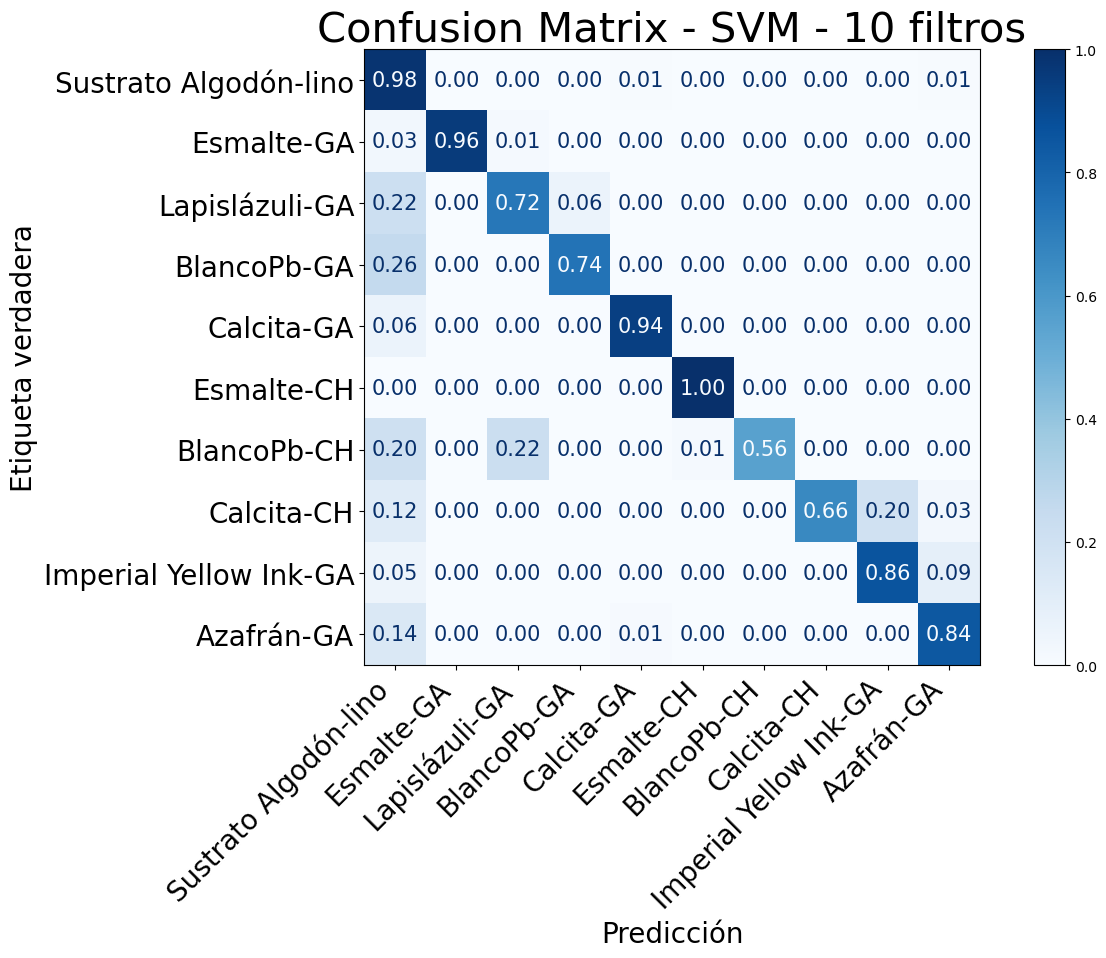

In [17]:
labels = np.unique(y_test)
display_labels = [class_names[l] for l in labels]

fig, ax = plt.subplots(figsize=(14, 8))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_10f,
    labels=labels,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - SVM - 10 filtros", fontsize=30)

for text in ax.texts:
    text.set_fontsize(15)

ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=20)
ax.set_yticklabels(display_labels, rotation=0, fontsize=20)

ax.set_xlabel("Predicción", fontsize=20)
ax.set_ylabel("Etiqueta verdadera", fontsize=20)

plt.show()

## Binarization and 6 filter system. The last experiment

In [18]:
def load_data():
    data = loadmat('dataset_without_substrate.mat')

    X_train = data['X_train']
    y_train = data['y_train'].ravel()

    X_test = data['X_test']
    y_test = data['y_test'].ravel()

    return X_train, y_train, X_test, y_test

#X variables are the pixels and Y variables are the labels
X_train, y_train, X_test, y_test = load_data()

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (39507, 121)
Train y: (39507,)
Test X: (9809, 121)
Test y: (9809,)


In [19]:
class_names = {
    #12: "Sustrato Algodón-lino",
    62: "Esmalte-GA",
    63: "Lapislázuli-GA",
    64: "BlancoPb-GA",
    65: "Calcita-GA",
    85: "Esmalte-CH",
    87: "BlancoPb-CH",
    88: "Calcita-CH",
    109: "Imperial Yellow Ink-GA",
    117: "Azafrán-GA",
}

In [20]:
def crear_multiespectral(X, filtros):                       #Creamos el sistema multiespectral
    canales = []                                            #hacemos una lista con los canales que tendría un sensor multiespectral

    for nombre, (bmin, bmax) in filtros.items():            #Recorremos cada filtro
        canal = X[:, bmin:bmax+1].mean(axis=1)              #Cogemos las muestras de la banda del filtro y las promediamos
        canales.append(canal)                               #$\text{canal} = \frac{1}{N} \sum_{i=bmin}^{bmax} X_i$

    return np.vstack(canales).T

In [21]:
X_train_6f = crear_multiespectral(X_train, filtros_6)
X_test_6f  = crear_multiespectral(X_test, filtros_6)

print(X_train_6f.shape)
print(X_test_6f.shape)

(39507, 6)
(9809, 6)


In [22]:
model_6f = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
])

model_6f.fit(X_train_6f, y_train)

y_pred_6f = model_6f.predict(X_test_6f)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred_6f))
print(classification_report(y_test, y_pred_6f, digits=4))

Accuracy: 0.8238352533387705
              precision    recall  f1-score   support

          62     0.9952    0.9673    0.9810       856
          63     0.6696    0.8655    0.7550       803
          64     0.7880    0.9432    0.8586       792
          65     0.8307    0.9973    0.9064       364
          85     0.9462    1.0000    0.9723       334
          87     1.0000    0.6763    0.8069      1001
          88     0.9975    0.6672    0.7996      2975
         109     0.6859    0.9040    0.7800      2094
         117     0.7222    0.9475    0.8196       590

    accuracy                         0.8238      9809
   macro avg     0.8483    0.8854    0.8533      9809
weighted avg     0.8628    0.8238    0.8242      9809



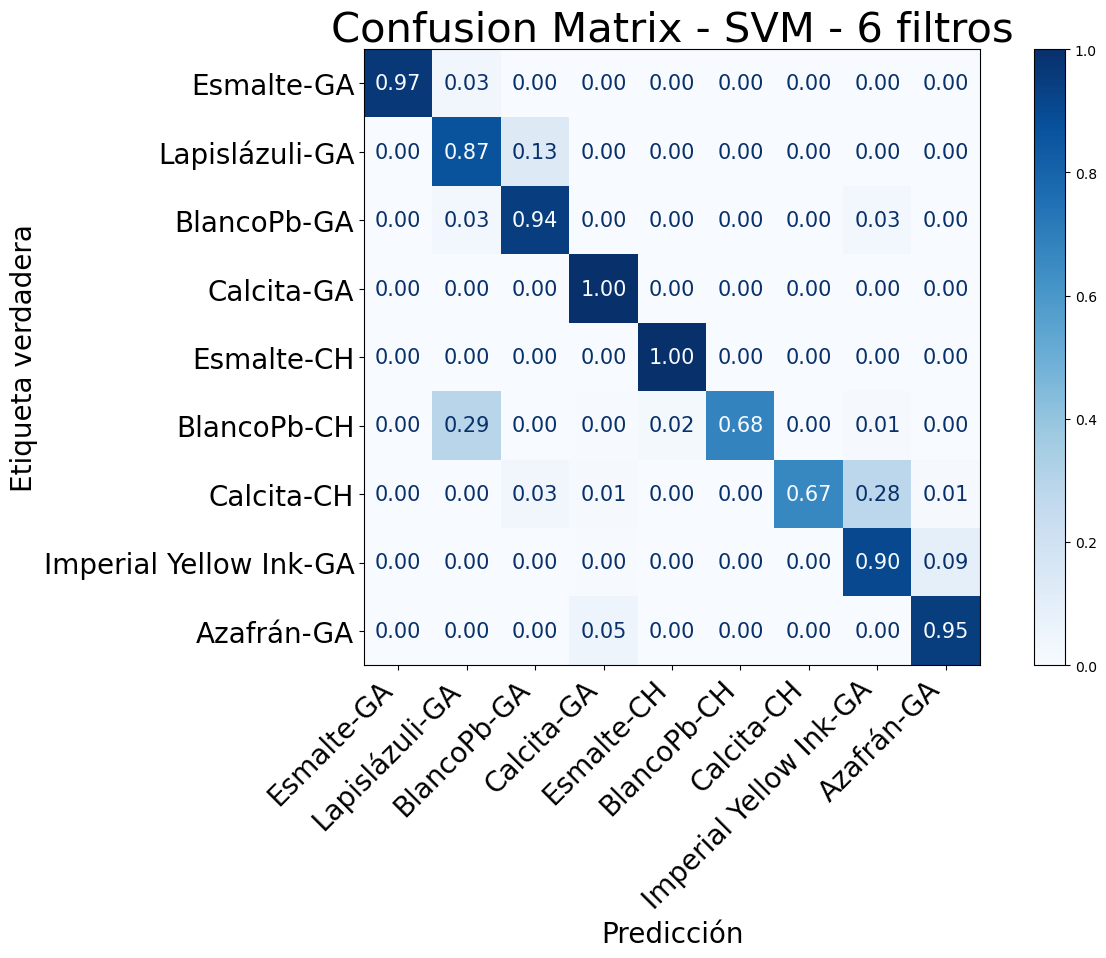

In [24]:
labels = np.unique(y_test)
display_labels = [class_names[l] for l in labels]

fig, ax = plt.subplots(figsize=(14, 8))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_6f,
    labels=labels,
    display_labels=display_labels,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - SVM - 6 filtros", fontsize=30)

for text in ax.texts:
    text.set_fontsize(15)

ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=20)
ax.set_yticklabels(display_labels, rotation=0, fontsize=20)

ax.set_xlabel("Predicción", fontsize=20)
ax.set_ylabel("Etiqueta verdadera", fontsize=20)

plt.show()